# Introduction

In this project, you will build a neural network of your own design to evaluate the MNIST dataset.

Some of the benchmark results on MNIST include can be found [on Yann LeCun's page](https://webcache.googleusercontent.com/search?q=cache:stAVPik6onEJ:yann.lecun.com/exdb/mnist) and include:

88% [Lecun et al., 1998](https://hal.science/hal-03926082/document)

95.3% [Lecun et al., 1998](https://hal.science/hal-03926082v1/document)

99.65% [Ciresan et al., 2011](http://people.idsia.ch/~juergen/ijcai2011.pdf)


MNIST is a great dataset for sanity checking your models, since the accuracy levels achieved by large convolutional neural networks and small linear models are both quite high. This makes it important to be familiar with the data.

## Installation

In [1]:
# Restart the Kernel after you execute this command.

!python -m pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 139 kB 3.2 MB/s eta 0:00:01
     |████████████████████████████████| 2.2 MB 34.4 MB/s eta 0:00:01
     |████████████████████████████████| 216 kB 44.3 MB/s eta 0:00:01


**Important: Restart the Kernel at this moment**

## Imports

In [1]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset

Specify your transforms as a list if you intend to .
The transforms module is already loaded as `transforms`.

MNIST is fortunately included in the torchvision module.
Then, you can create your dataset using the `MNIST` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/vision/stable/datasets.html#mnist)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [2]:
# Define transforms
## YOUR CODE HERE ##
transform = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.1307,), (0.3081,))
                               ])
# Create training set and define training dataloader
## YOUR CODE HERE ##
train_data = torchvision.datasets.MNIST(root="~/torch_datasets", train= True, transform = transform, download=True)

train_len = int(0.8 * len(train_data))
valid_len = len(train_data) - train_len
train_subset, valid_subset = torch.utils.data.random_split(train_data, [train_len, valid_len])
train_loader = torch.utils.data.DataLoader(train_data, batch_size = 32, shuffle = True)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size = 32, shuffle = False)
# Create test set and define test dataloader
## YOUR CODE HERE ##
test_data = torchvision.datasets.MNIST(root="~/torch_datasets", train= False, transform = transform, download=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size = 32, shuffle = False)

Failed to download (trying next):
HTTP Error 404: Not Found




Extracting /root/torch_datasets/MNIST/raw/train-images-idx3-ubyte.gz to /root/torch_datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found




Extracting /root/torch_datasets/MNIST/raw/train-labels-idx1-ubyte.gz to /root/torch_datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found




Extracting /root/torch_datasets/MNIST/raw/t10k-images-idx3-ubyte.gz to /root/torch_datasets/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found




Extracting /root/torch_datasets/MNIST/raw/t10k-labels-idx1-ubyte.gz to /root/torch_datasets/MNIST/raw



/opt/conda/lib/python3.7/site-packages/torchvision/datasets/mnist.py:498: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  ../torch/csrc/utils/tensor_numpy.cpp:178.)
  return torch.from_numpy(parsed.astype(m[2], copy=False)).view(*s)


## Justify your preprocessing

Since the images are stored as PIL so I used transforms.ToTensor() which turns these pictures into pixel values [0,255] and normalised to make the optimization smoother. In DataLoader I chose batch size 32 so the network can be trained on 32 images in one batch and shuffle as True, so  the order of samples retrieved from train data will be randomized in each epoch.

**DOUBLE CLICK THIS CELL TO MODIFY**

## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [3]:
## This cell contains a function for showing 5 images from a dataloader – DO NOT CHANGE THE CONTENTS! ##
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(int(labels[i].detach()))
    
        image = images[i].numpy()
        plt.imshow(image.T.squeeze().T)
        plt.show()

9


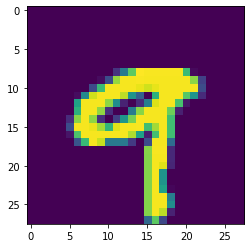

2


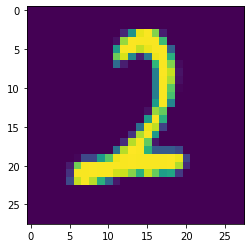

0


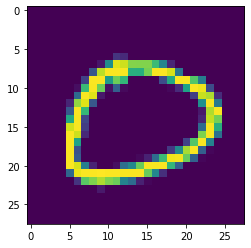

7


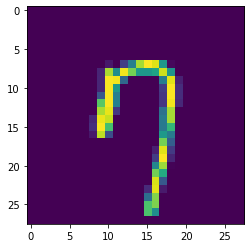

8


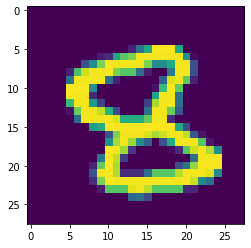

In [4]:
# Explore data
## YOUR CODE HERE ##
show5(train_loader)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset.
Use any architecture you like. 

*Note*: If you did not flatten your tensors in your transforms or as part of your preprocessing and you are using only `Linear` layers, make sure to use the `Flatten` layer in your network!

In [5]:
## YOUR CODE HERE ##
class Net(nn.Module):
    def __init__(self):
        
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512,128)
        self.fc3 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = x.view(-1, 28*28)
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x= self.fc3(x)
        return x
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net().to(device)
print(model)
    

Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [6]:
## YOUR CODE HERE ##
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss **during** each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [7]:
## YOUR CODE HERE ##

train_losses = []
val_losses = []

for epoch in range(1,21):
    model.train()
    training_loss = 0.0
    correct = 0
    total=0
    
    for batch_idx,(data, labels) in enumerate(train_loader):
        #data and labels to cuda
        data, labels = data.to(device), labels.to(device)
        
                
        outputs = model(data)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        training_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        if (batch_idx+1)%250==0:
            print(f" Epoch {epoch} ---Batch {batch_idx+1} -- Loss {loss.item()}")
            
    training_accuracy = correct/total
    average_training_loss = training_loss/len(train_loader)
        
    model.eval()
        
    valid_loss = 0.0
    correct=0
    total = 0
        
    with torch.no_grad():
        for data, labels in valid_loader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            loss = criterion(outputs, labels)
            valid_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    valid_acc = correct/total
    avg_valid_loss = valid_loss/len(valid_loader)
    
    train_losses.append(average_training_loss)
    val_losses.append(avg_valid_loss)
        
            
    print(f"Epoch {epoch} — Train Loss: {average_training_loss:.4f}, Train Acc: {training_accuracy:.4f}")
    print(f"Valid Loss: {avg_valid_loss:.4f}, Valid Acc: {valid_acc:.4f}")
        
        
        
        
        

 Epoch 1 ---Batch 250 -- Loss 0.8593521118164062
 Epoch 1 ---Batch 500 -- Loss 0.2952917218208313
 Epoch 1 ---Batch 750 -- Loss 0.5767080783843994
 Epoch 1 ---Batch 1000 -- Loss 0.2849629521369934
 Epoch 1 ---Batch 1250 -- Loss 0.2563341557979584
 Epoch 1 ---Batch 1500 -- Loss 0.11920744180679321
 Epoch 1 ---Batch 1750 -- Loss 0.2793109714984894
Epoch 1 — Train Loss: 0.5369, Train Acc: 0.8601
Valid Loss: 0.2619, Valid Acc: 0.9246
 Epoch 2 ---Batch 250 -- Loss 0.07630307972431183
 Epoch 2 ---Batch 500 -- Loss 0.21039538085460663
 Epoch 2 ---Batch 750 -- Loss 0.16064147651195526
 Epoch 2 ---Batch 1000 -- Loss 0.10202492773532867
 Epoch 2 ---Batch 1250 -- Loss 0.2273743748664856
 Epoch 2 ---Batch 1500 -- Loss 0.2176843136548996
 Epoch 2 ---Batch 1750 -- Loss 0.20550787448883057
Epoch 2 — Train Loss: 0.2268, Train Acc: 0.9346
Valid Loss: 0.1868, Valid Acc: 0.9467
 Epoch 3 ---Batch 250 -- Loss 0.42446303367614746
 Epoch 3 ---Batch 500 -- Loss 0.19600367546081543
 Epoch 3 ---Batch 750 -- Los

Plot the training loss (and validation loss/accuracy, if recorded).

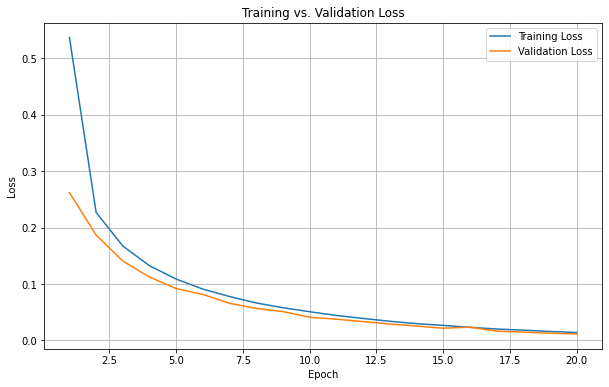

In [8]:
## YOUR CODE HERE ##

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Training Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 90%, great work, but see if you can push a bit further! 
If your accuracy is under 90%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [9]:
## YOUR CODE HERE ##

model.eval()

test_loss = 0
test_correct = 0
test_total = 0
        

for data, labels in test_loader:
    data, labels = data.to(device), labels.to(device)
    
    outputs = model(data)
    loss = criterion(outputs, labels)
    
    test_loss += loss.item()
    _, preds = torch.max(outputs, 1)
    test_correct += (preds==labels).sum().item()
    test_total += labels.size(0)

test_avg_loss = test_loss/len(test_loader)
test_acc = test_correct/test_total   

print(f" Test Loss: {test_avg_loss:.4f}, Test Acc: {test_acc:.4f}")
    

 Test Loss: 0.0626, Test Acc: 0.9811


## Improving your model

Once your model is done training, try tweaking your hyperparameters and training again below to improve your accuracy on the test set!

In [10]:
## YOUR CODE HERE ##
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay =1e-4)

In [11]:

train_losses = []
val_losses = []

for epoch in range(1,21):
    model.train()
    training_loss = 0.0
    correct = 0
    total=0
    
    for batch_idx,(data, labels) in enumerate(train_loader):
        #data and labels to cuda
        data, labels = data.to(device), labels.to(device)
        
                
        outputs = model(data)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        training_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        if (batch_idx+1)%250==0:
            print(f" Epoch {epoch} ---Batch {batch_idx+1} -- Loss {loss.item()}")
            
    training_accuracy = correct/total
    average_training_loss = training_loss/len(train_loader)
        
    model.eval()
        
    valid_loss = 0.0
    correct=0
    total = 0
        
    with torch.no_grad():
        for data, labels in valid_loader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            loss = criterion(outputs, labels)
            valid_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    valid_acc = correct/total
    avg_valid_loss = valid_loss/len(valid_loader)
    
    train_losses.append(average_training_loss)
    val_losses.append(avg_valid_loss)
        
            
    print(f"Epoch {epoch} — Train Loss: {average_training_loss:.4f}, Train Acc: {training_accuracy:.4f}")
    print(f"Valid Loss: {avg_valid_loss:.4f}, Valid Acc: {valid_acc:.4f}")

 Epoch 1 ---Batch 250 -- Loss 0.007806090638041496
 Epoch 1 ---Batch 500 -- Loss 0.00237830076366663
 Epoch 1 ---Batch 750 -- Loss 0.00679619237780571
 Epoch 1 ---Batch 1000 -- Loss 0.005894157569855452
 Epoch 1 ---Batch 1250 -- Loss 0.018350642174482346
 Epoch 1 ---Batch 1500 -- Loss 0.005032149609178305
 Epoch 1 ---Batch 1750 -- Loss 0.003089055884629488
Epoch 1 — Train Loss: 0.0126, Train Acc: 0.9983
Valid Loss: 0.0102, Valid Acc: 0.9990
 Epoch 2 ---Batch 250 -- Loss 0.03274822235107422
 Epoch 2 ---Batch 500 -- Loss 0.04250792786478996
 Epoch 2 ---Batch 750 -- Loss 0.0741347223520279
 Epoch 2 ---Batch 1000 -- Loss 0.048994217067956924
 Epoch 2 ---Batch 1250 -- Loss 0.0004532728053163737
 Epoch 2 ---Batch 1500 -- Loss 0.012165362015366554
 Epoch 2 ---Batch 1750 -- Loss 0.0196733009070158
Epoch 2 — Train Loss: 0.0115, Train Acc: 0.9986
Valid Loss: 0.0100, Valid Acc: 0.9990
 Epoch 3 ---Batch 250 -- Loss 0.012039721012115479
 Epoch 3 ---Batch 500 -- Loss 0.0012401207350194454
 Epoch 3 -

## Saving your model
Using `torch.save`, save your model for future loading.

In [12]:
model.eval()

test_loss = 0
test_correct = 0
test_total = 0
        

for data, labels in test_loader:
    data, labels = data.to(device), labels.to(device)
    
    outputs = model(data)
    loss = criterion(outputs, labels)
    
    test_loss += loss.item()
    _, preds = torch.max(outputs, 1)
    test_correct += (preds==labels).sum().item()
    test_total += labels.size(0)

test_avg_loss = test_loss/len(test_loader)
test_acc = test_correct/test_total   

print(f" Test Loss: {test_avg_loss:.4f}, Test Acc: {test_acc:.4f}")

 Test Loss: 0.0642, Test Acc: 0.9812


In [15]:
## YOUR CODE HERE ##
PATH = "model_state_dict.pth"
torch.save(model.state_dict(), PATH)